# SUPG advection-diffusion of a Gaussian in an interval

Donea, J. & Huerta, A. (2003). *Finite Element Methods for Flow Problems*. $\S 5.6.1$

$$
\mathbb{S}
\begin{cases}
\Omega = [0, 1] & \text{unit interval} \\
u_0(x) = \mu\exp\left(-(x-x_0)^2/\sigma^2\right) & \text{Gaussian initial condition} \\
u_{\text{D}}(x=0,1)=0 & \text{Dirichlet boundary conditions} \\
\textbf{a}=a\,\textbf{e}_x & \text{constant velocity} \\
\mathsf{D}=D\mathsf{I} & \text{constant isotropic diffusivity} \\
R=0 & \text{zero reaction} \\
J=0 & \text{zero source} \\ \hline
u_{\text{e}}(x, t)=\frac{\mu}{\sqrt{1+4Dt/\sigma^2}}\exp\left(-\frac{(x-x_0-at)^2}{\sigma^2+4Dt}\right) & \text{exact solution} \\
Pe = \frac{a}{2DN_x} & \text{local Peclet number}
\end{cases}
$$

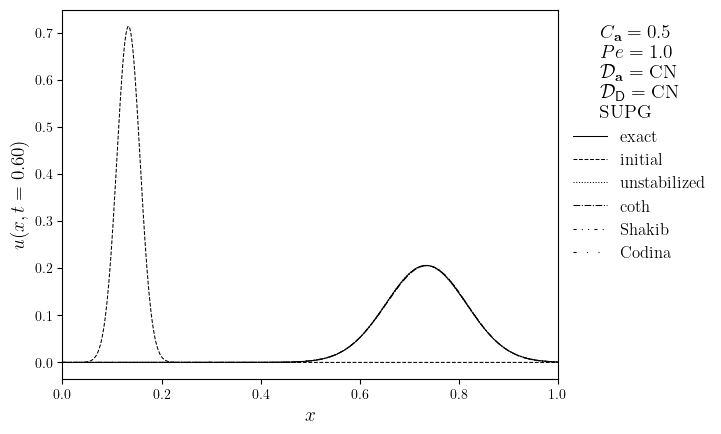

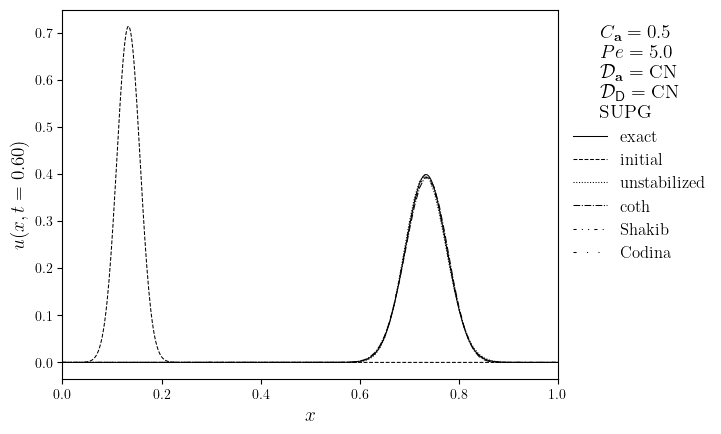

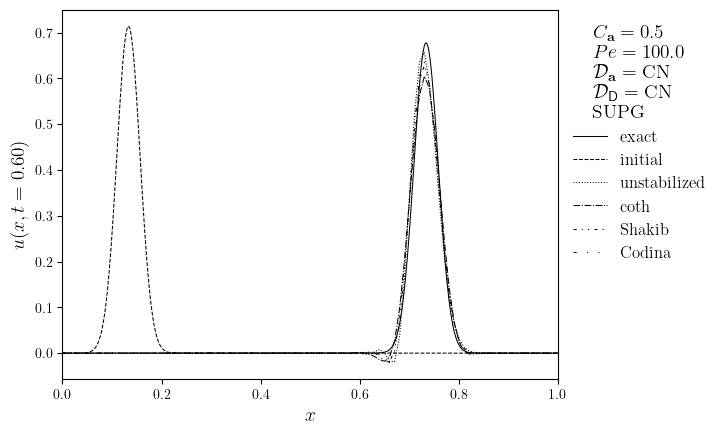

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fem import Constant
from lucifex.fdm import (
    CN, advective_timestep, peclet_argument, FiniteDifference, FunctionSeries, ConstantSeries, finite_difference_order,
)
from lucifex.solver import ibvp , BoundaryConditions
from lucifex.sim import Simulation, run
from lucifex.viz import plot_line, save_figure
from lucifex.utils.array_utils import as_index
from lucifex.utils.py_utils import nested_dict
from lucifex.pde.advection_diffusion import advection_diffusion

def exact_solution(
    x,
    t,
    a,
    d,
    sigma,
    mu,
    x0,
):
    factor = (mu / np.sqrt(1 + 4 * d * t / sigma**2)) 
    func = np.exp(-(x - x0 - a * t)**2 / (sigma**2 + 4 * d * t))
    return factor * func


def create_simulation(
    supg: str | None,
    Lx: float,
    Nx: int,
    dt: float,
    a: float,
    d: float,
    D_adv: FiniteDifference,
    D_diff: FiniteDifference,
    mu: float,
    x0: float,
    sigma: float,
    cache_matrix: bool = False,
) -> Simulation:
    order = finite_difference_order(D_adv, D_diff)
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    a = Constant(mesh, (a, ), name='a')
    d = Constant(mesh, d, name='d')
    u = FunctionSeries((mesh, 'P', 1), name='u', order=order, store=1)
    ics = lambda x: exact_solution(x[0], 0.0, a.value[0], d.value, sigma, mu, x0)
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], 0.0),
        ('dirichlet', lambda x: x[0] - Lx, 0.0),
    )
    u_solver = ibvp(advection_diffusion, ics, bcs, cache_matrix=cache_matrix)(
        u, dt, a, d, D_adv, D_diff, supg=supg,
    )
    return Simulation([u_solver], t, dt)

Lx = 1.0
Nx = 100
h = Lx / Nx

a = 1.0
courant = 0.5
dt = advective_timestep(a, h, courant)

D_adv = CN
D_diff = CN

mu = 5/7
x0 = 2/15
sigma = 7 * np.sqrt(2) / 300

Pe_opts = (1.0, 5.0, 100.0)
supg_opts = (None, 'coth', 'shakib', 'codina')
simulations = nested_dict((str, float, Simulation))

for supg in supg_opts:
    for Pe in Pe_opts:
        d = peclet_argument(Pe, h=h, a=a)
        simulations[supg][Pe] = create_simulation(supg, Lx, Nx, dt, a, d, D_adv, D_diff, mu, x0, sigma)

t_stop = 0.7
for supg in supg_opts:
    for Pe in Pe_opts:
        run(simulations[supg][Pe], t_stop=t_stop) 

x = np.linspace(0, Lx, num=500)
t_target = 0.6
for Pe in Pe_opts:
    legend_title = '\n'.join(
        (
            f'$C_{{\mathbf{{a}}}}={courant}$',
            f'$Pe={Pe:.1f}$',
            f'$\mathcal{{D}}_{{\mathbf{{a}}}}=\mathrm{{{D_adv.name}}}$',
            f'$\mathcal{{D}}_{{\mathsf{{D}}}}=\mathrm{{{D_diff.name}}}$',
            '\nSUPG',
        )
    )
    d = peclet_argument(Pe, h=h, a=a)
    ue = exact_solution(x, t_target, a, d, sigma, mu, x0)
    u0 = exact_solution(x, 0.0, a, d, sigma, mu, x0)
    lines = [(x, ue), (x, u0)]
    legend_labels = ['exact', 'initial']
    for supg in supg_opts:
        u = simulations[supg][Pe]['u']
        time_index = as_index(u.time_series, t_target, func=lambda x, y: np.isclose(x, y))
        t = u.time_series[time_index]
        lines.append(u.series[time_index])
        if supg is None:
            supg = 'unstabilized'
        if supg in ('shakib', 'codina'):
            supg = supg.capitalize()
        legend_labels.append(supg)    
    fig, ax = plot_line(
        lines, legend_labels, legend_title, 
        x_lims=x, 
        x_label='$x$', 
        y_label=f'$u(x,t={t:.2f})$',
    )
    thumbnail = (Pe is Pe_opts[-1])
    save_figure(f'Pe={Pe:.1f}_C_{{\mathbf{{a}}}}={courant}_Dadv={D_adv.name}_Ddiff={D_diff.name}', thumbnail=thumbnail)(fig)